# <font color="brown">Credit Default Prediction with an sklearn Pipeline </font>

## <font color = "brown">Problem Statement </font>

### <font color="blue"> Context

The `Decision Trees` case study built a credit-default classifier on this same customer dataset by
manually one-hot encoding every categorical column with `pd.get_dummies` before doing anything
else. That works, but it has a real risk: any preprocessing done once, up front, outside of
cross-validation gets fit on the full training set before the CV folds even exist, and it's easy
to forget and quietly repeat that mistake on new data at prediction time. `sklearn`'s `Pipeline`
fixes this by bundling preprocessing and the model into a single object that is fit fresh inside
every cross-validation fold, and reused unchanged at prediction time.

### <font color="blue"> Objective

- Bundle the categorical encoding and the Decision Tree model into one `Pipeline` using
  `make_pipeline`, instead of encoding by hand.
- Confirm the pipeline reaches the same result as the manual approach in `Decision Trees`.
- Tune the pipeline's hyperparameters directly with `GridSearchCV`, using the
  `step_name__parameter` naming convention.

### <font color="blue"> Data Dictionary

Same dataset as the `Decision Trees` case study (`default_on_payment.csv`, 5,000 customers): credit
history, account status, loan amount, employment, and demographic fields, with
`Default_On_Payment` (1 = defaulted, 0 = repaid) as the target.

## <font color="brown"> Importing Necessary Libraries</font>

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import make_pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay

%matplotlib inline

## <font color="brown"> Reading the Data</font>

In [2]:
df = pd.read_csv("../Decision Trees/default_on_payment.csv")
df = df.drop(columns=["Customer_ID"])
print(df.shape)
df.head()

(5000, 21)


,Status_Checking_Acc,Duration_in_Months,Credit_History,Purposre_Credit_Taken,Credit_Amount,Savings_Acc,Years_At_Present_Employment,Inst_Rt_Income,Marital_Status_Gender,Other_Debtors_Guarantors,...,Property,Age,Other_Inst_Plans,Housing,Num_CC,Job,Dependents,Telephone,Foreign_Worker,Default_On_Payment
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,...,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,...,A121,22,A143,A152,1,A173,1,A191,A201,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,...,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,...,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,...,A124,53,A143,A153,2,A173,2,A191,A201,1


In [3]:
X = df.drop(columns=["Default_On_Payment"])
y = df["Default_On_Payment"]

categorical_cols = X.select_dtypes(include="object").columns.tolist()
numeric_cols = X.select_dtypes(exclude="object").columns.tolist()

print(f"{len(categorical_cols)} categorical columns, {len(numeric_cols)} numeric columns")

13 categorical columns, 7 numeric columns


C:\Users\yoges\AppData\Local\Temp\ipykernel_16576\4286556705.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include="object").columns.tolist()


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (3500, 20)  Test: (1500, 20)


## <font color="brown"> Building the Pipeline</font>

A `ColumnTransformer` says *how* to preprocess each group of columns: one-hot encode the
categorical ones, leave the numeric ones alone (a Decision Tree doesn't need scaling, unlike a
distance-based or linear model). `make_pipeline` then chains that preprocessing step directly into
the model, so the whole thing behaves as a single estimator with one `.fit()` and one `.predict()`:

In [5]:
preprocessor = ColumnTransformer(
    transformers=[("encode", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_cols)],
    remainder="passthrough",
)

pipe = make_pipeline(preprocessor, DecisionTreeClassifier(random_state=0))
pipe

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('columntransformer', ...), ('decisiontreeclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('encode', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float,

Notice `X_train` still has the raw, un-encoded categorical columns (`A11`, `A12`, ...) going into
`pipe.fit()` below, no `pd.get_dummies` step beforehand. The pipeline handles that internally:

In [6]:
pipe.fit(X_train, y_train)

pred_train = pipe.predict(X_train)
pred_test = pipe.predict(X_test)

print("Train recall:", round(recall_score(y_train, pred_train), 3))
print("Test recall: ", round(recall_score(y_test, pred_test), 3))

Train recall: 1.0
Test recall:  0.834


This lands on essentially the same result as the unrestricted base tree in `Decision Trees`
(100% train recall, ~83% test recall), the same overfitting pattern, for the same reason: a fully
grown tree memorises the training data regardless of whether the categorical columns were encoded
by hand or inside a pipeline. The pipeline changes *how safely* the preprocessing is wired in, not
what the underlying model does.

## <font color="brown"> Tuning the Pipeline with GridSearchCV</font>

`GridSearchCV` can tune parameters of any step inside a pipeline directly, addressed as
`stepname__parameter`. `make_pipeline` auto-names each step from its class name in lowercase, so
the Decision Tree step is addressed as `decisiontreeclassifier__...`. Because the whole pipeline
(encoding included) is refit inside every cross-validation fold, there's no risk of the encoding
being fit on data outside that fold:

In [7]:
param_grid = {
    "decisiontreeclassifier__max_depth": [3, 4, 5, 6, 7],
    "decisiontreeclassifier__min_samples_leaf": [5, 10, 20, 30],
}

grid_search = GridSearchCV(pipe, param_grid, scoring="recall", cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)

Best parameters: {'decisiontreeclassifier__max_depth': 7, 'decisiontreeclassifier__min_samples_leaf': 5}


In [8]:
best_pipe = grid_search.best_estimator_

pred_train_tuned = best_pipe.predict(X_train)
pred_test_tuned = best_pipe.predict(X_test)

comparison = pd.DataFrame({
    "Train Recall": [
        recall_score(y_train, pred_train),
        recall_score(y_train, pred_train_tuned),
    ],
    "Test Recall": [
        recall_score(y_test, pred_test),
        recall_score(y_test, pred_test_tuned),
    ],
}, index=["Baseline Pipeline", "Tuned Pipeline"]).round(3)
comparison

,Train Recall,Test Recall
Baseline Pipeline,1.000,0.834
Tuned Pipeline,0.756,0.782


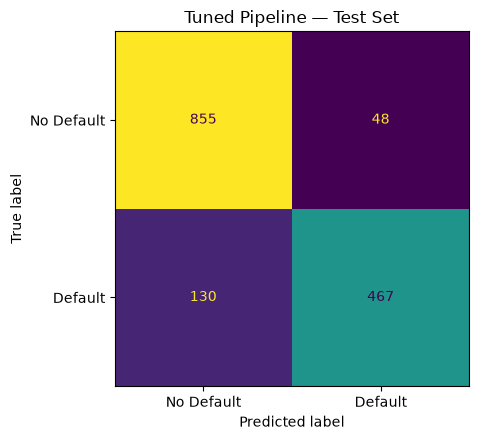

In [9]:
fig, ax = plt.subplots(figsize=(5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_test_tuned, display_labels=["No Default", "Default"], ax=ax, colorbar=False
)
ax.set_title("Tuned Pipeline — Test Set")
plt.tight_layout()
plt.show()

Tuning `max_depth` and `min_samples_leaf` closes most of the train-test gap the baseline pipeline
showed, the same pre-pruning effect demonstrated manually in `Decision Trees`, reached here with
one `GridSearchCV` call over the whole pipeline instead of a separate encode-then-tune sequence.

## <font color="brown"> Business Insights and Recommendations</font>

- **The pipeline reproduces the manual result exactly.** Baseline pipeline recall (100% train,
  83.4% test) matches the `Decision Trees` case study's unrestricted base tree number for number,
  confirming `ColumnTransformer` + `OneHotEncoder` inside a pipeline encodes the categorical
  columns equivalently to the manual `pd.get_dummies` approach, with none of the manual encoding
  code.

- **Tuning the pipeline directly finds the same answer as tuning by hand.** `GridSearchCV` over
  `decisiontreeclassifier__max_depth` and `decisiontreeclassifier__min_samples_leaf` landed on
  `max_depth=7, min_samples_leaf=5`, the exact same combination `Decision Trees` found by
  searching over hand-encoded data, and the exact same result (75.6% train / 78.2% test recall).
  Wrapping preprocessing in the pipeline didn't cost anything in model quality.

- **What actually changed is safety, not accuracy.** Because the whole pipeline (encoding
  included) is refit inside every one of `GridSearchCV`'s 5 folds, there's no way to accidentally
  fit the encoder on data outside a fold, the exact leakage risk that a manual "encode once, then
  cross-validate" workflow leaves open. The identical numbers here show that safety came for free.

- **Recommendation**: default to wrapping any preprocessing + model combination in a `Pipeline`
  (via `make_pipeline` for the simple case, or `Pipeline` with explicit step names when more
  control over naming is needed) before tuning, rather than encoding data by hand first. It's less
  code, and it removes an entire category of leakage mistakes, with no accuracy cost, as
  demonstrated here.